This is the clustering code.
It will temporarily drop filepath and class columns, and cluster the rows.
In the last cell it will save all images of the same cluster in a folder.

In [9]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

In [44]:
# Change these paths accordingly

clustering_output_path = '/Users/sinner/PycharmProjects/SML_Project/FINAL_FILES/USL_Clustering_Package/Clustering_output'
feature_df_path = '/Users/sinner/PycharmProjects/SML_Project/FINAL_FILES/USL_Clustering_Package/clustering_features_df.csv'

In [11]:
# Read feature dataframe csv

feature_df = pd.read_csv(feature_df_path)
feature_df.head()

,filepath,dissimilarity,correlation,homogeneity,contrast,ASM,energy,mean_r,mean_g,mean_b,...,Bin_21,Bin_22,Bin_23,Bin_24,Bin_25,Bin_26,Bin_27,Bin_28,Bin_29,class
0,/Users/sinner/Desktop/waste_only_images_all/00...,18.923771,0.759237,0.085817,785.858455,0.000174,0.013178,4.656550,4.672133,4.669419,...,0.192270,0.183969,0.397666,0.598897,0.427903,0.254003,0.196526,0.180164,0.285649,1
1,/Users/sinner/Desktop/waste_only_images_all/42...,13.545805,0.799017,0.110258,409.500687,0.000266,0.016306,4.614077,4.617764,4.630562,...,0.109459,0.113770,0.399140,0.683249,0.486938,0.218707,0.125231,0.137112,0.166869,1
2,/Users/sinner/Desktop/waste_only_images_all/35...,23.779350,0.539249,0.063523,1198.639625,0.000201,0.014193,4.495674,4.470425,4.471587,...,0.131142,0.190444,0.463232,0.632157,0.448661,0.233819,0.131819,0.119620,0.197390,1
3,/Users/sinner/Desktop/waste_only_images_all/26...,16.856000,0.773274,0.081487,583.762113,0.000135,0.011633,4.486680,4.482031,4.499627,...,0.069346,0.075007,0.346575,0.771139,0.471487,0.166829,0.084200,0.083803,0.100030,1
4,/Users/sinner/Desktop/waste_only_images_all/51...,10.517836,0.451345,0.110380,212.400119,0.000769,0.027726,4.642310,4.638205,4.624247,...,0.238023,0.197424,0.425098,0.540527,0.422710,0.245984,0.202996,0.200608,0.307281,1


In [13]:
X = feature_df.drop(columns=['filepath', 'class'])

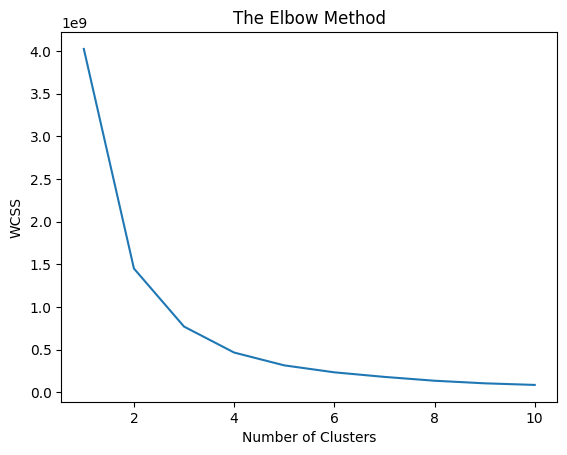

In [14]:
wcss=[]
for i in range (1,11):
    kmeans=KMeans (n_clusters=i, n_init=10, init= 'k-means++',random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot (range (1, 11), wcss)
plt.title( 'The Elbow Method')
plt.xlabel ('Number of Clusters')
plt.ylabel ('WCSS')
plt.show()

In [38]:
# Define no. of clusters of KMeans here
n_clusters=4

# instantiate a KMeans object
kmeans = KMeans(n_clusters=n_clusters, n_init=10)

In [39]:
# fit the KMeans object to your dataframe
kmeans.fit(feature_df.drop(columns=['filepath', 'class']))

KMeans(n_clusters=4, n_init=10)

In [40]:
# add a new column to your dataframe with the cluster labels
feature_df['cluster'] = kmeans.labels_

In [41]:
# Make different folder for different clusters
for i in range(n_clusters):
    cluster_folder_path = os.path.join(clustering_output_path, str(i))
    # Create cluster folder if doesn't exist
    if not os.path.exists(cluster_folder_path):
        os.mkdir(cluster_folder_path)

# Iterate all rows to read image and save into respective folders
for index, row in feature_df.iterrows():
    img = cv2.imread(row['filepath'])
    cv2.imwrite(os.path.join(clustering_output_path, str(row['cluster']),  f'{row["class"]}_{index}.jpg' ), img)

In [42]:
import numpy as np
from sklearn import metrics

def purity_score(y_true, y_pred):
    # compute contingency matrix (also called confusion matrix)
    contingency_matrix = metrics.cluster.contingency_matrix(y_true, y_pred)
    # return purity
    return np.sum(np.amax(contingency_matrix, axis=0)) / np.sum(contingency_matrix)

In [48]:
for n_clusters in range(1,10):
    # Read feature dataframe csv
    feature_df = pd.read_csv(feature_df_path)

    # instantiate a KMeans object
    kmeans = KMeans(n_clusters=n_clusters, n_init=10)

    # fit the KMeans object to your dataframe
    kmeans.fit(feature_df.drop(columns=['filepath', 'class']))

    # add a new column to your dataframe with the cluster labels
    feature_df['cluster'] = kmeans.labels_

    print(f"n_clusters = {n_clusters}. Purity = ", end="")
    print(purity_score(feature_df["class"], feature_df["cluster"]))

n_clusters = 1. Purity = 0.5184415584415585
n_clusters = 2. Purity = 0.5899567099567099
n_clusters = 3. Purity = 0.6272727272727273
n_clusters = 4. Purity = 0.6411255411255411
n_clusters = 5. Purity = 0.6438961038961039
n_clusters = 6. Purity = 0.6406060606060606
n_clusters = 7. Purity = 0.6374025974025974
n_clusters = 8. Purity = 0.6392207792207792
n_clusters = 9. Purity = 0.6422510822510823


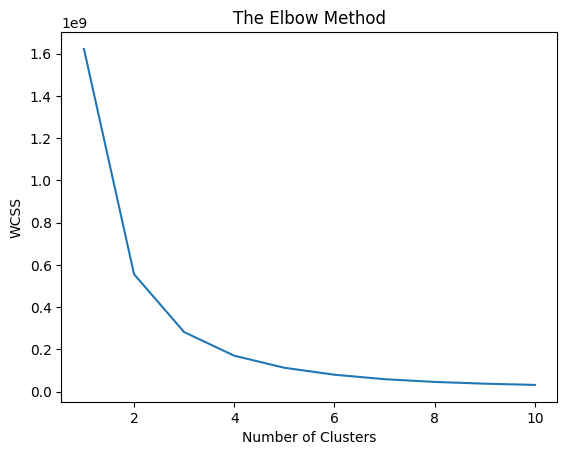

In [32]:
X = feature_df[feature_df["class"] ==0].drop(columns=['filepath', 'class'])

wcss=[]
for i in range (1,11):
    kmeans=KMeans (n_clusters=i, n_init=10, init= 'k-means++',random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot (range (1, 11), wcss)
plt.title( 'The Elbow Method')
plt.xlabel ('Number of Clusters')
plt.ylabel ('WCSS')
plt.show()

In [36]:
n_clusters=10

class_1_df = feature_df[feature_df["class"] == 0]

# instantiate a KMeans object
kmeans = KMeans(n_clusters=n_clusters, n_init=10)

# fit the KMeans object to your dataframe
kmeans.fit(class_1_df.drop(columns=["filepath", "class"]))

# add a new column to your dataframe with the cluster labels
class_1_df['cluster'] = kmeans.labels_

# Make different folder for different clusters
for i in range(n_clusters):
    cluster_folder_path = os.path.join(clustering_output_path, str(i))
    # Create cluster folder if doesn't exist
    if not os.path.exists(cluster_folder_path):
        os.mkdir(cluster_folder_path)

# Iterate all rows to read image and save into respective folders
for index, row in class_1_df.iterrows():
    img = cv2.imread(row['filepath'])
    cv2.imwrite(os.path.join(clustering_output_path, str(row['cluster']),  f'{row["class"]}_{index}.jpg' ), img)

/var/folders/z2/14rgf6cd42159h5c22zxvs1h0000gn/T/ipykernel_4050/1156589709.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  class_1_df['cluster'] = kmeans.labels_
